In [3]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, accuracy_score

ENG_PATH  = "processed/floodsense_engineered.csv"
PLOTS_DIR = "engineered_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [4]:
df = pd.read_csv(ENG_PATH)
df["date"] = pd.to_datetime(df["date"])

target  = "flood_event"
exclude = ["date", target, "district"]
all_features = [c for c in df.columns if c not in exclude]

water_area_features = [c for c in all_features if "water_area_km2_lag" in c]
print(f"Water_area_lag features identified: {len(water_area_features)}")
for f in water_area_features:
    print(f"  - {f}")

Water_area_lag features identified: 6
  - water_area_km2_lag1
  - water_area_km2_lag2
  - water_area_km2_lag3
  - water_area_km2_lag1_zscore
  - water_area_km2_lag2_zscore
  - water_area_km2_lag3_zscore


In [5]:
variant_A_features = all_features
variant_B_features = [c for c in all_features if c not in water_area_features]
variant_C_features = water_area_features + ["month", "is_monsoon", "avg_elevation_m"]

print(f"Variant A (Full):            {len(variant_A_features)} features")
print(f"Variant B (No water_area):   {len(variant_B_features)} features")
print(f"Variant C (Only water_area): {len(variant_C_features)} features")

Variant A (Full):            47 features
Variant B (No water_area):   41 features
Variant C (Only water_area): 9 features


In [6]:
groups = df["district"]
y = df[target].values
gkf = GroupKFold(n_splits=3)

params = {
    "objective": "binary", "metric": "auc",
    "learning_rate": 0.05, "num_leaves": 31, "min_data_in_leaf": 20,
    "feature_fraction": 0.9, "bagging_fraction": 0.8, "bagging_freq": 5,
    "is_unbalance": True, "verbose": -1, "random_state": 42,
}

def run_variant(features, name):
    X = df[features].replace([np.inf, -np.inf], np.nan)
    oof_preds = np.zeros(len(df))
    fold_aucs, fold_districts, fold_imp = [], [], []

    print(f"\n--- {name} ({len(features)} features) ---")
    for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X, y, groups), start=1):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        held_out = df.iloc[vl_idx]["district"].iloc[0]
        fold_districts.append(held_out)

        train_data = lgb.Dataset(X_tr, label=y_tr)
        val_data   = lgb.Dataset(X_vl, label=y_vl, reference=train_data)

        model = lgb.train(
            params, train_data, num_boost_round=2000,
            valid_sets=[val_data], valid_names=["val"],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        )
        preds = model.predict(X_vl, num_iteration=model.best_iteration)
        oof_preds[vl_idx] = preds

        fold_auc = roc_auc_score(y_vl, preds)
        fold_aucs.append(fold_auc)
        fold_imp.append(model.feature_importance(importance_type="gain"))
        print(f"  Fold {fold} (held-out: {held_out:25s}): AUC = {fold_auc:.4f}")

    overall_auc = roc_auc_score(y, oof_preds)
    acc = accuracy_score(y, (oof_preds >= 0.5).astype(int))

    importance_df = pd.DataFrame({
        "feature":    features,
        "importance": np.mean(fold_imp, axis=0),
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return dict(name=name, n_features=len(features), fold_aucs=fold_aucs,
                fold_districts=fold_districts, overall_auc=overall_auc,
                accuracy=acc, importance_df=importance_df)

In [7]:
print("=" * 75)
print("RUNNING SENSITIVITY TEST")
print("=" * 75)
result_A = run_variant(variant_A_features, "A — Full engineered")

RUNNING SENSITIVITY TEST

--- A — Full engineered (47 features) ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	val's auc: 0.96335
  Fold 1 (held-out: Sindh_District           ): AUC = 0.9633
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[65]	val's auc: 0.98146
  Fold 2 (held-out: Balochistan_District     ): AUC = 0.9815
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	val's auc: 0.96904
  Fold 3 (held-out: KP_District              ): AUC = 0.9690


In [8]:
result_B = run_variant(variant_B_features, "B — No water_area")


--- B — No water_area (41 features) ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[14]	val's auc: 0.571168
  Fold 1 (held-out: Sindh_District           ): AUC = 0.5712
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[26]	val's auc: 0.606675
  Fold 2 (held-out: Balochistan_District     ): AUC = 0.6067
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[10]	val's auc: 0.583958
  Fold 3 (held-out: KP_District              ): AUC = 0.5840


In [9]:
result_C = run_variant(variant_C_features, "C — Only water_area + minimal context")


--- C — Only water_area + minimal context (9 features) ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[227]	val's auc: 0.968654
  Fold 1 (held-out: Sindh_District           ): AUC = 0.9687
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[65]	val's auc: 0.983324
  Fold 2 (held-out: Balochistan_District     ): AUC = 0.9833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[44]	val's auc: 0.975563
  Fold 3 (held-out: KP_District              ): AUC = 0.9756


In [10]:
print("=" * 75)
print("SENSITIVITY TEST RESULTS")
print("=" * 75)

districts_order = ["Sindh_District", "Balochistan_District", "KP_District"]

def auc_for_district(result, district):
    idx = result["fold_districts"].index(district)
    return result["fold_aucs"][idx]

rows = []
for r in [result_A, result_B, result_C]:
    rows.append({
        "Variant":     r["name"],
        "# feats":     r["n_features"],
        "Overall AUC": f"{r['overall_auc']:.4f}",
        "Sindh":       f"{auc_for_district(r, 'Sindh_District'):.4f}",
        "Balochistan": f"{auc_for_district(r, 'Balochistan_District'):.4f}",
        "KP":          f"{auc_for_district(r, 'KP_District'):.4f}",
        "Accuracy":    f"{r['accuracy']:.4f}",
    })
print(pd.DataFrame(rows).to_string(index=False))

SENSITIVITY TEST RESULTS
                              Variant  # feats Overall AUC  Sindh Balochistan     KP Accuracy
                  A — Full engineered       47      0.9561 0.9633      0.9815 0.9690   0.9092
                    B — No water_area       41      0.5768 0.5712      0.6067 0.5840   0.6564
C — Only water_area + minimal context        9      0.9528 0.9687      0.9833 0.9756   0.9165


In [11]:
print("=" * 75)
print("TOP 10 FEATURES PER VARIANT")
print("=" * 75)

for r in [result_A, result_B, result_C]:
    print(f"\n{r['name']} (AUC = {r['overall_auc']:.4f}):")
    print(r["importance_df"].head(10).to_string(index=False))

TOP 10 FEATURES PER VARIANT

A — Full engineered (AUC = 0.9561):
                   feature  importance
water_area_km2_lag1_zscore 2582.732589
       water_area_km2_lag1 2429.730579
       water_area_km2_lag3 1414.537607
       water_area_km2_lag2 1303.813686
water_area_km2_lag2_zscore  793.828370
water_area_km2_lag3_zscore  564.614659
        pressure_drop_1day  124.512522
      temperature_7day_avg   66.305510
 soil_moisture_change_3day   59.394400
        precipitation_lag7   59.249954

B — No water_area (AUC = 0.5768):
                  feature  importance
soil_moisture_change_3day  263.399879
       pressure_drop_1day  256.167273
                 pressure  241.692168
            pressure_lag1  211.741681
       precipitation_lag5  195.866355
       precipitation_lag3  187.027844
       precipitation_lag7  163.040442
  precipitation_14day_sum  159.086624
       temperature_zscore  151.034380
               wind_speed  149.388535

C — Only water_area + minimal context (AUC = 0.9528)

In [12]:
print("=" * 75)
print("DIAGNOSIS")
print("=" * 75)

A_auc, B_auc, C_auc = result_A["overall_auc"], result_B["overall_auc"], result_C["overall_auc"]

print(f"""
Full engineered (A):                    {A_auc:.4f}
Without water_area (B):                 {B_auc:.4f}
Only water_area + context (C):          {C_auc:.4f}

Contribution of water_area (A − B):      {A_auc - B_auc:+.4f}
Contribution of everything else (A − C): {A_auc - C_auc:+.4f}
""")

if B_auc >= 0.75:
    verdict = ("ROBUST — model works well on weather/soil features alone.\n"
               "  Pitch frame: 'system continues to function with delayed satellite data'")
elif B_auc >= 0.65:
    verdict = ("PARTIALLY DEPENDENT — water_area contributes meaningfully but isn't required.\n"
               "  Pitch frame: 'satellite data improves accuracy but isn't strictly required'")
else:
    verdict = ("HEAVILY DEPENDENT — model relies on water_area lags to be reliable.\n"
               "  Pitch frame: 'system requires daily satellite imagery; designed around it'")

print(f"VERDICT: {verdict}")

DIAGNOSIS

Full engineered (A):                    0.9561
Without water_area (B):                 0.5768
Only water_area + context (C):          0.9528

Contribution of water_area (A − B):      +0.3793
Contribution of everything else (A − C): +0.0033

VERDICT: HEAVILY DEPENDENT — model relies on water_area lags to be reliable.
  Pitch frame: 'system requires daily satellite imagery; designed around it'


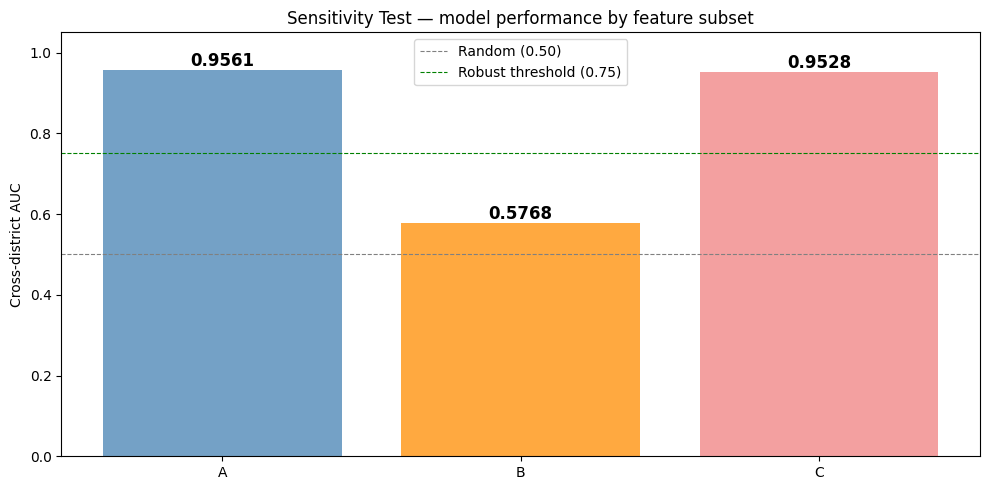

In [13]:
colors = ["steelblue", "darkorange", "lightcoral"]

fig, ax = plt.subplots(figsize=(10, 5))
labels = [r["name"].split(" — ")[0] for r in [result_A, result_B, result_C]]
aucs   = [A_auc, B_auc, C_auc]
bars = ax.bar(labels, aucs, color=colors, alpha=0.75)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{auc:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(y=0.5,  color="grey",  linestyle="--", linewidth=0.8, label="Random (0.50)")
ax.axhline(y=0.75, color="green", linestyle="--", linewidth=0.8, label="Robust threshold (0.75)")
ax.set_ylabel("Cross-district AUC")
ax.set_title("Sensitivity Test — model performance by feature subset")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sensitivity_overall.png", dpi=80)
plt.show()
plt.close()

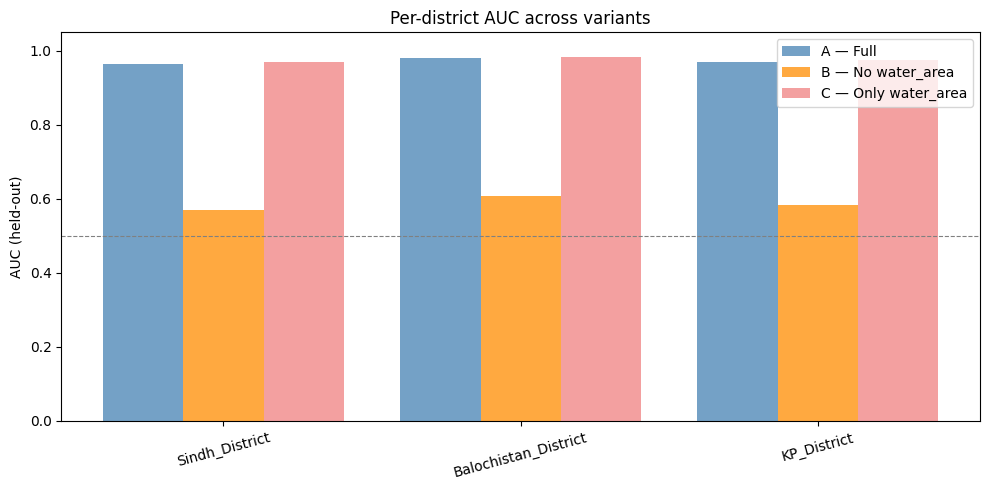

Plots saved to engineered_plots/


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(districts_order))
width = 0.27
for i, (r, c, lab) in enumerate(zip(
    [result_A, result_B, result_C],
    colors,
    ["A — Full", "B — No water_area", "C — Only water_area"]
)):
    fold_in_order = [auc_for_district(r, d) for d in districts_order]
    ax.bar(x + (i - 1) * width, fold_in_order, width, label=lab, color=c, alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(districts_order, rotation=15)
ax.set_ylabel("AUC (held-out)")
ax.set_title("Per-district AUC across variants")
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sensitivity_per_district.png", dpi=80)
plt.show()
plt.close()

print(f"Plots saved to {PLOTS_DIR}/")